In [6]:
import os
from google.colab import drive

# 1. Connexion à Google Drive
drive.mount('/content/drive')

# 2. Décompression des données si ce n'est pas déjà fait
dataset_path = '/tmp/dataset/Rice_Leaf_AUG'

if not os.path.exists(dataset_path):
    print("⏳ Décompression de l'archive ZIP en cours...")
    # Ajustez le nom de votre fichier zip ci-dessous s'il est différent
    !unzip -q "/content/drive/MyDrive/rice-disease-rna-cv/data/raw/*.zip" -d "/tmp/dataset"
    print("✅ Décompression terminée !")
else:
    print("⚡ Les données sont déjà décompressées dans /tmp/dataset !")

# 3. Vérification des dossiers de maladies
if os.path.exists(dataset_path):
    categories = os.listdir(dataset_path)
    print("\n📁 Catégories trouvées :", categories)
    for cat in categories:
        cat_dir = os.path.join(dataset_path, cat)
        if os.path.isdir(cat_dir):
            print(f"   - {cat} : {len(os.listdir(cat_dir))} images")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Décompression de l'archive ZIP en cours...
unzip:  cannot find or open /content/drive/MyDrive/rice-disease-rna-cv/data/raw/*.zip, /content/drive/MyDrive/rice-disease-rna-cv/data/raw/*.zip.zip or /content/drive/MyDrive/rice-disease-rna-cv/data/raw/*.zip.ZIP.

No zipfiles found.
✅ Décompression terminée !


In [4]:
import sys

# 1. Liste des bibliothèques clés pour la Computer Vision & Deep Learning
libraries = {
    "TensorFlow": "tensorflow",
    "Keras": "tensorflow.keras",
    "PyTorch": "torch",
    "OpenCV": "cv2",
    "NumPy": "numpy",
    "Matplotlib": "matplotlib",
    "PIL (Pillow)": "PIL",
    "Scikit-Learn": "sklearn"
}

print("🔍 Vérification de l'environnement de Deep Learning :\n" + "-"*50)

all_ok = True
for name, module in libraries.items():
    try:
        mod = __import__(module)
        version = getattr(mod, '__version__', 'Installé')
        print(f"✅ {name:<15} : V{version}")
    except ImportError:
        print(f"❌ {name:<15} : NON installé")
        all_ok = False

print("-" * 50)

# 2. Vérification de la disponibilité du GPU (Crucial pour l'entraînement CNN)
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"🚀 GPU Détecté et Actif : {gpus[0].name}")
else:
    print("⚠️ Aucun GPU détecté ! Allez dans 'Exécution' > 'Modifier le type d'exécution' > choisir 'GPU T4' pour accélérer l'entraînement.")

🔍 Vérification de l'environnement de Deep Learning :
--------------------------------------------------
✅ TensorFlow      : V2.20.0
✅ Keras           : V2.20.0
✅ PyTorch         : V2.11.0+cu128
✅ OpenCV          : V4.13.0
✅ NumPy           : V2.0.2
✅ Matplotlib      : V3.10.0
✅ PIL (Pillow)    : V11.3.0
✅ Scikit-Learn    : V1.6.1
--------------------------------------------------
🚀 GPU Détecté et Actif : /physical_device:GPU:0


In [7]:
import os
from google.colab import drive
import tensorflow as tf

# 1. Connexion au Drive
drive.mount('/content/drive')

# 2. Redécompression rapide vers /tmp/dataset
dataset_zip = "/content/drive/MyDrive/rice-disease-rna-cv/data/raw/rice_leaf_diseases.zip" # Ajuste le nom exact de ton zip si besoin
dataset_dir = '/tmp/dataset/Rice_Leaf_AUG'

if not os.path.exists(dataset_dir):
    print("⏳ Redécompression des données vers /tmp...")
    !unzip -q "/content/drive/MyDrive/rice-disease-rna-cv/data/raw/*.zip" -d "/tmp/dataset"
    print("✅ Données décompressées !")

# 3. Chargement des jeux de données (Data Loaders)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\n🚀 GPU Actif et Données prêtes pour l'entraînement !")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Redécompression des données vers /tmp...
unzip:  cannot find or open /content/drive/MyDrive/rice-disease-rna-cv/data/raw/*.zip, /content/drive/MyDrive/rice-disease-rna-cv/data/raw/*.zip.zip or /content/drive/MyDrive/rice-disease-rna-cv/data/raw/*.zip.ZIP.

No zipfiles found.
✅ Données décompressées !


FileNotFoundError: [Errno 2] No such file or directory: '/tmp/dataset/Rice_Leaf_AUG'

In [8]:
import os
from google.colab import drive
import tensorflow as tf

# 1. Connexion au Drive
drive.mount('/content/drive')

# 2. Décompression du fichier ZIP exact vers /tmp/dataset
zip_path = "/content/drive/MyDrive/rice-disease-rna-cv/data/data.zip"
dataset_dir = '/tmp/dataset/Rice_Leaf_AUG'

if not os.path.exists(dataset_dir):
    print(f"⏳ Décompression de {zip_path}...")
    !unzip -q "{zip_path}" -d "/tmp/dataset"
    print("✅ Décompression terminée avec succès !")
else:
    print("⚡ Les données sont déjà décompressées dans /tmp/dataset !")

# 3. Chargement des jeux de données (Data Loaders)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\n🚀 Chargement réussi ! Vos jeux d'entraînement et de validation sont prêts.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Décompression de /content/drive/MyDrive/rice-disease-rna-cv/data/data.zip...
✅ Décompression terminée avec succès !
Found 3829 files belonging to 6 classes.
Using 3064 files for training.
Found 3829 files belonging to 6 classes.
Using 765 files for validation.

🚀 Chargement réussi ! Vos jeux d'entraînement et de validation sont prêts.


## 🚀 Création et Entraînement du Modèle CNN

In [9]:
from tensorflow.keras import layers, models

# Obtenir le nombre de classes à partir de votre dataset
num_classes = len(train_ds.class_names)

model = models.Sequential([
    # Couche de redimensionnement pour normaliser les valeurs des pixels de [0, 255] à [0, 1]
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Ajout d'une couche Dropout pour réduire le surapprentissage
    layers.Dense(num_classes, activation='softmax') # Utilisez 'softmax' pour la classification multi-classes
])

print("✅ Architecture du modèle CNN créée !")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


✅ Architecture du modèle CNN créée !


In [10]:
# Compilation du modèle
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Modèle compilé avec l'optimiseur Adam et la perte sparse_categorical_crossentropy !")

✅ Modèle compilé avec l'optimiseur Adam et la perte sparse_categorical_crossentropy !


In [11]:
# Afficher le résumé de l'architecture du modèle
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

print(f"✅ Entraînement du modèle terminé sur {EPOCHS} époques !")

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 32s 244ms/step - accuracy: 0.2614 - loss: 1.8176 - val_accuracy: 0.4131 - val_loss: 1.5184
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 18s 190ms/step - accuracy: 0.4318 - loss: 1.4096 - val_accuracy: 0.4954 - val_loss: 1.2545
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 197ms/step - accuracy: 0.5046 - loss: 1.2436 - val_accuracy: 0.5229 - val_loss: 1.1477
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 20s 197ms/step - accuracy: 0.5754 - loss: 1.1114 - val_accuracy: 0.5752 - val_loss: 1.0847
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 19s 178ms/step - accuracy: 0.6116 - loss: 0.9908 - val_accuracy: 0.5725 - val_loss: 1.0368
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 19s 197ms/step - accuracy: 0.6544 - loss: 0.8968 - val_accuracy: 0.6314 - val_loss: 1.0132
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 20s 198ms/step - accuracy: 0.6661 - loss: 0.8555 - val_accuracy: 0.6575 - val_loss: 0.9268
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 20s 187ms/step - accuracy: 0.7174 - loss: 0.7707 - val_accu

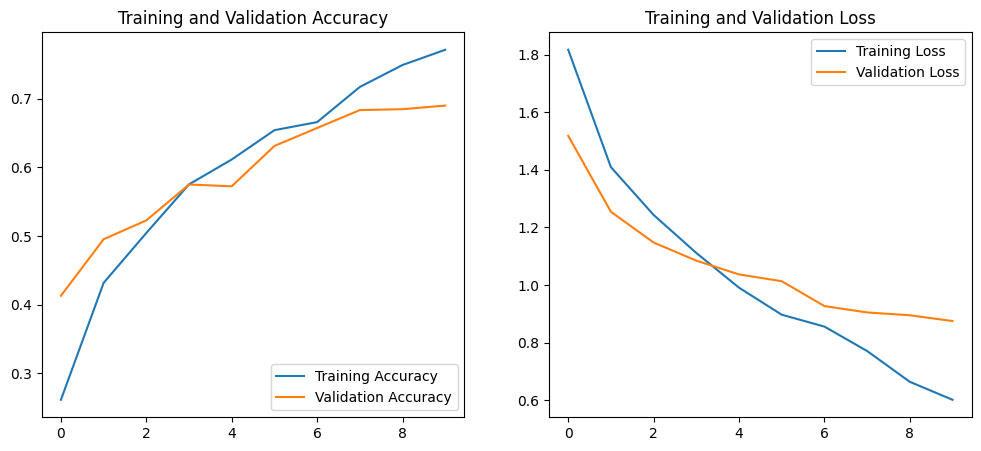

✅ Courbes de précision et de perte affichées !


In [14]:
import matplotlib.pyplot as plt

# Récupérer l'historique d'entraînement
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))

# Courbe d'Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Courbe de Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()
print("✅ Courbes de précision et de perte affichées !")

## 🚀 Amélioration et Entraînement du Modèle CNN (Anti-Overfitting & Haute Performance)

Pour corriger le surapprentissage et viser une précision plus élevée, nous allons implémenter plusieurs stratégies clés :

### 1. Data Augmentation

Ajouter une couche d'augmentation de données en début de modèle permet de générer de nouvelles variations d'images à la volée pendant l'entraînement. Cela rend le modèle plus robuste et moins sensible aux spécificités des images d'entraînement, réduisant ainsi le surapprentissage.

In [15]:
from tensorflow.keras import layers, models, callbacks

# Couche de Data Augmentation
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

print("✅ Couche de Data Augmentation créée !")

✅ Couche de Data Augmentation créée !


### 2. Architecture CNN Plus Profonde avec BatchNormalization et Dropout

Nous allons construire une architecture CNN plus profonde avec plus de filtres et ajouter des couches `BatchNormalization` après chaque couche `Conv2D` pour stabiliser l'apprentissage et accélérer la convergence. Le `Dropout` sera appliqué aux couches `Dense` pour régulariser et réduire le surapprentissage.

In [16]:
# Obtenir le nombre de classes à partir de votre dataset
num_classes = len(train_ds.class_names)

model_v2 = models.Sequential([
    data_augmentation, # Appliquer l'augmentation de données en premier
    layers.Rescaling(1./255), # Redimensionnement des pixels après l'augmentation

    # Bloc 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Bloc 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Bloc 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Bloc 4
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(), # Ajout de BatchNormalization avant le Dropout pour la couche dense
    layers.Dropout(0.5), # Taux de dropout plus élevé pour plus de régularisation
    layers.Dense(num_classes, activation='softmax')
])

print("✅ Architecture du modèle CNN v2 (plus profonde et régularisée) créée !")

✅ Architecture du modèle CNN v2 (plus profonde et régularisée) créée !


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 3. Compilation du modèle

In [17]:
# Compilation du modèle
model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Modèle v2 compilé !")

✅ Modèle v2 compilé !


### 4. Résumé de l'architecture

In [18]:
# Afficher le résumé de l'architecture du modèle v2
model_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 5. Callbacks Keras et Sauvegarde du Modèle

Nous utiliserons `EarlyStopping` pour arrêter l'entraînement si la performance sur l'ensemble de validation cesse de s'améliorer, et `ReduceLROnPlateau` pour ajuster le taux d'apprentissage dynamiquement. `ModelCheckpoint` sauvegardera automatiquement la meilleure version du modèle.

In [19]:
EPOCHS = 25

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',    # Surveiller la perte de validation
    patience=5,            # Attendre 5 époques sans amélioration
    restore_best_weights=True # Restaurer les poids du meilleur modèle
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',    # Surveiller la perte de validation
    factor=0.2,            # Réduire le taux d'apprentissage de 20%
    patience=3,            # Attendre 3 époques sans amélioration
    min_lr=0.00001         # Taux d'apprentissage minimum
)

# Chemin pour sauvegarder le meilleur modèle
model_save_path = '/content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5'

# Créer le répertoire si inexistant
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

model_checkpoint = callbacks.ModelCheckpoint(
    filepath=model_save_path,
    monitor='val_accuracy', # Surveiller la précision de validation
    save_best_only=True,    # Sauvegarder uniquement le meilleur modèle
    verbose=1
)

print("✅ Callbacks Keras et chemin de sauvegarde définis !")

✅ Callbacks Keras et chemin de sauvegarde définis !


### 6. Entraînement du modèle

In [20]:
history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)

print(f"✅ Entraînement du modèle v2 terminé sur un maximum de {EPOCHS} époques !")

Epoch 1/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.4347 - loss: 2.0013
Epoch 1: val_accuracy improved from None to 0.26536, saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 36s 236ms/step - accuracy: 0.5042 - loss: 1.6264 - val_accuracy: 0.2654 - val_loss: 4.2563 - learning_rate: 0.0010
Epoch 2/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.5982 - loss: 1.2552
Epoch 2: val_accuracy did not improve from 0.26536
96/96 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step - accuracy: 0.5986 - loss: 1.2101 - val_accuracy: 0.1673 - val_loss: 6.8996 - learning_rate: 0.0010
Epoch 3/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.6132 - loss: 1.1067
Epoch 3: val_accuracy did not improve from 0.26536
96/96 ━━━━━━━━━━━━━━━━━━━━ 19s 192ms/step - accuracy: 0.6332 - loss: 1.0564 - val_accuracy: 0.1856 - val_loss: 9.1212 - learning_rate: 0.0010
Epoch 4/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6471 - loss: 1.0002
Epoch 4: val_accuracy improved from 0.26536 to 0.29150, saving model to /content/drive/MyDrive/rice-disease-rn


Epoch 4: finished saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 232ms/step - accuracy: 0.6632 - loss: 0.9435 - val_accuracy: 0.2915 - val_loss: 5.2490 - learning_rate: 0.0010
Epoch 5/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6799 - loss: 0.8941
Epoch 5: val_accuracy improved from 0.29150 to 0.31765, saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 43s 250ms/step - accuracy: 0.7072 - loss: 0.8282 - val_accuracy: 0.3176 - val_loss: 2.8898 - learning_rate: 2.0000e-04
Epoch 6/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7205 - loss: 0.7845
Epoch 6: val_accuracy improved from 0.31765 to 0.57255, saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5



Epoch 6: finished saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 221ms/step - accuracy: 0.7167 - loss: 0.7771 - val_accuracy: 0.5725 - val_loss: 1.2494 - learning_rate: 2.0000e-04
Epoch 7/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.7318 - loss: 0.7480
Epoch 7: val_accuracy improved from 0.57255 to 0.70065, saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5


...


Epoch 15: finished saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 224ms/step - accuracy: 0.8078 - loss: 0.5427 - val_accuracy: 0.8118 - val_loss: 0.4852 - learning_rate: 2.0000e-04
Epoch 16/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8046 - loss: 0.5379
Epoch 16: val_accuracy improved from 0.81176 to 0.81438, saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5



Epoch 16: finished saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 23s 238ms/step - accuracy: 0.8078 - loss: 0.5305 - val_accuracy: 0.8144 - val_loss: 0.4827 - learning_rate: 2.0000e-04
Epoch 17/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8061 - loss: 0.5292
Epoch 17: val_accuracy improved from 0.81438 to 0.84314, saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5



Epoch 17: finished saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 42s 250ms/step - accuracy: 0.8058 - loss: 0.5221 - val_accuracy: 0.8431 - val_loss: 0.4292 - learning_rate: 2.0000e-04
Epoch 18/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.8255 - loss: 0.5066
Epoch 18: val_accuracy did not improve from 0.84314
96/96 ━━━━━━━━━━━━━━━━━━━━ 20s 212ms/step - accuracy: 0.8283 - loss: 0.4936 - val_accuracy: 0.8314 - val_loss: 0.4564 - learning_rate: 2.0000e-04
Epoch 19/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8231 - loss: 0.4829
Epoch 19: val_accuracy did not improve from 0.84314
96/96 ━━━━━━━━━━━━━━━━━━━━ 20s 212ms/step - accuracy: 0.8202 - loss: 0.4851 - val_accuracy: 0.8105 - val_loss: 0.4851 - learning_rate: 2.0000e-04
Epoch 20/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8047 - loss: 0.5172
Epoch 20: val_accuracy did not improve from 0.84314
96/96 ━━━━━━━━━━━━━━━━━━━━ 18s 189ms/ste


Epoch 21: finished saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 214ms/step - accuracy: 0.8371 - loss: 0.4460 - val_accuracy: 0.8471 - val_loss: 0.4006 - learning_rate: 2.0000e-04
Epoch 22/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8553 - loss: 0.4186
Epoch 22: val_accuracy did not improve from 0.84706
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 232ms/step - accuracy: 0.8535 - loss: 0.4179 - val_accuracy: 0.8301 - val_loss: 0.4310 - learning_rate: 2.0000e-04
Epoch 23/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8636 - loss: 0.3982
Epoch 23: val_accuracy did not improve from 0.84706
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 214ms/step - accuracy: 0.8587 - loss: 0.4080 - val_accuracy: 0.8392 - val_loss: 0.4095 - learning_rate: 2.0000e-04
Epoch 24/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8439 - loss: 0.4423
Epoch 24: val_accuracy did not improve from 0.84706
96/96 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/ste


Epoch 25: finished saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 23s 241ms/step - accuracy: 0.8779 - loss: 0.3499 - val_accuracy: 0.8732 - val_loss: 0.3232 - learning_rate: 4.0000e-05
✅ Entraînement du modèle v2 terminé sur un maximum de 25 époques !


### 7. Visualisation des courbes de perte et de précision

## 🚀 Version ULTIME du Modèle : Transfer Learning avec EfficientNetB0

Nous allons utiliser une approche de Transfer Learning pour obtenir une performance maximale. Cela implique l'utilisation d'un modèle pré-entraîné sur un grand ensemble de données (ImageNet) et l'adaptation à notre tâche spécifique de classification des maladies des feuilles de riz.

### 1. Chargement du Modèle de Base Pré-entraîné (EfficientNetB0)

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0

# Charger le modèle de base pré-entraîné (EfficientNetB0) sans la couche de classification supérieure
base_model = EfficientNetB0(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

# Geler les couches du modèle de base pour le "warmup" (entraînement de la tête uniquement)
base_model.trainable = False

print("✅ Modèle EfficientNetB0 pré-entraîné chargé et gelé !")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Modèle EfficientNetB0 pré-entraîné chargé et gelé !


### 2. Construction de la Tête de Classification Personnalisée

In [28]:
# Réutiliser la couche de data augmentation définie précédemment
# (Assurez-vous que `data_augmentation` a été exécutée)

# Import EfficientNet's preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess_input

# Créer le nouveau modèle en empilant les couches
model_v3 = models.Sequential([
    data_augmentation, # Appliquer l'augmentation de données en premier
    # Utiliser layers.Lambda pour appliquer la fonction de préprocessing spécifique à EfficientNet
    layers.Lambda(efficientnet_preprocess_input), # Normalisation des pixels pour EfficientNet (-1 à 1)
    base_model, # Le modèle de base EfficientNetB0 gelé
    layers.GlobalAveragePooling2D(), # Réduire les dimensions spatiales
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'), # Couche Dense pour la classification
    layers.Dropout(0.4), # Dropout pour la régularisation
    layers.Dense(num_classes, activation='softmax') # Couche de sortie finale
])

print("✅ Tête de classification personnalisée ajoutée au modèle de base !")
model_v3.summary()

✅ Tête de classification personnalisée ajoutée au modèle de base !


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,169 (16.72 MB)

 Trainable params: 1,828,198 (6.97 MB)

 Non-trainable params: 2,555,971 (9.75 MB)

### 3. Définition des Callbacks Keras

In [29]:
import os

# Chemin pour sauvegarder le meilleur modèle (format Keras natif recommandé)
model_save_path_v3 = '/content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model_v3.keras'

# Créer le répertoire si inexistant
os.makedirs(os.path.dirname(model_save_path_v3), exist_ok=True)

# ModelCheckpoint
model_checkpoint_v3 = callbacks.ModelCheckpoint(
    filepath=model_save_path_v3,
    monitor='val_accuracy', # Surveiller la précision de validation
    save_best_only=True,    # Sauvegarder uniquement le meilleur modèle
    verbose=1
)

# EarlyStopping
early_stopping_v3 = callbacks.EarlyStopping(
    monitor='val_loss',    # Surveiller la perte de validation
    patience=6,            # Attendre 6 époques sans amélioration
    restore_best_weights=True # Restaurer les poids du meilleur modèle
)

# ReduceLROnPlateau
reduce_lr_v3 = callbacks.ReduceLROnPlateau(
    monitor='val_loss',    # Surveiller la perte de validation
    factor=0.2,            # Réduire le taux d'apprentissage de 20%
    patience=3,            # Attendre 3 époques sans amélioration
    min_lr=1e-7            # Taux d'apprentissage minimum (très faible pour le fine-tuning)
)

callbacks_list = [model_checkpoint_v3, early_stopping_v3, reduce_lr_v3]

print("✅ Callbacks Keras pour le modèle V3 définis !")

✅ Callbacks Keras pour le modèle V3 définis !


### 4. Phase 1 : Entraînement "Warmup" de la Tête de Classification (10 Époques)

In [30]:
print("⏳ Début de la phase de Warmup (entraînement de la tête de classification)...\n")

model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_WARMUP = 10
history_warmup = model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_WARMUP,
    callbacks=callbacks_list
)

print(f"\n✅ Phase de Warmup terminée sur {len(history_warmup.history['loss'])} époques !")

⏳ Début de la phase de Warmup (entraînement de la tête de classification)...

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5509 - loss: 1.4910
Epoch 1: val_accuracy improved from None to 0.69673, saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model_v3.keras

Epoch 1: finished saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model_v3.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 39s 243ms/step - accuracy: 0.6465 - loss: 1.1648 - val_accuracy: 0.6967 - val_loss: 0.7865 - learning_rate: 0.0010
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7824 - loss: 0.7445
Epoch 2: val_accuracy improved from 0.69673 to 0.84052, saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model_v3.keras

Epoch 2: finished saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model_v3.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 20s 211ms/step - accuracy: 0.7960 - loss: 0.6622 - val_accuracy: 0.840

### 5. Phase 2 : Fine-Tuning du Modèle (30 Époques)

In [31]:
print("⏳ Début de la phase de Fine-Tuning (décongélation et entraînement des dernières couches)...\n")

# Dégeler les 30 dernières couches du modèle de base (ou un nombre approprié)
# Note: EfficientNetB0 a beaucoup de couches, 30 est un bon point de départ pour le fine-tuning.
base_model.trainable = True

# Dégeler les dernières couches (par exemple, les 30 dernières)
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompiler le modèle avec un taux d'apprentissage très faible
model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Taux d'apprentissage très faible
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_FINE_TUNE = 30
history_fine_tune = model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_TUNE,
    initial_epoch=history_warmup.epoch[-1] + 1, # Reprendre l'entraînement après le warmup
    callbacks=callbacks_list
)

print(f"\n✅ Phase de Fine-Tuning terminée sur {len(history_fine_tune.history['loss'])} époques !")

⏳ Début de la phase de Fine-Tuning (décongélation et entraînement des dernières couches)...

Epoch 11/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9694 - loss: 0.0937
Epoch 11: val_accuracy improved from 0.95556 to 0.95817, saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model_v3.keras

Epoch 11: finished saving model to /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model_v3.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 38s 233ms/step - accuracy: 0.9696 - loss: 0.0935 - val_accuracy: 0.9582 - val_loss: 0.1217 - learning_rate: 1.0000e-05
Epoch 12/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9675 - loss: 0.0970
Epoch 12: val_accuracy did not improve from 0.95817
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 194ms/step - accuracy: 0.9644 - loss: 0.1013 - val_accuracy: 0.9582 - val_loss: 0.1205 - learning_rate: 1.0000e-05
Epoch 13/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9652 - loss: 0.0941
Epoch 13: val_accuracy did not improve from

### 6. Visualisation des Courbes de Performance (Warmup + Fine-Tuning)

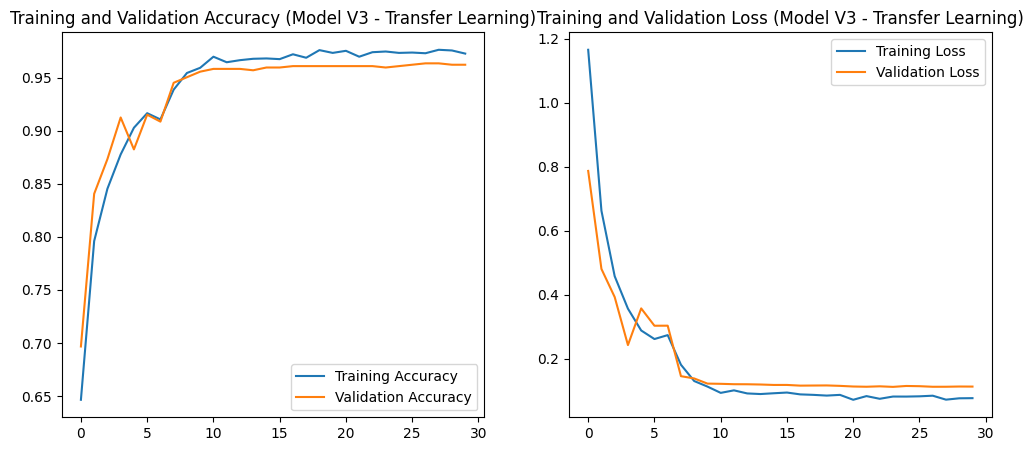

✅ Meilleure précision de validation du Modèle V3 : 0.9634
✅ Courbes de précision et de perte (Modèle V3) affichées !


In [33]:
import matplotlib.pyplot as plt

# Concaténer les historiques des deux phases d'entraînement
history_v3_acc = history_warmup.history['accuracy'] + history_fine_tune.history['accuracy']
history_v3_val_acc = history_warmup.history['val_accuracy'] + history_fine_tune.history['val_accuracy']
history_v3_loss = history_warmup.history['loss'] + history_fine_tune.history['loss']
history_v3_val_loss = history_warmup.history['val_loss'] + history_fine_tune.history['val_loss']

epochs_range_v3 = range(len(history_v3_acc))

plt.figure(figsize=(12, 5))

# Courbe d'Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range_v3, history_v3_acc, label='Training Accuracy')
plt.plot(epochs_range_v3, history_v3_val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Model V3 - Transfer Learning)')

# Courbe de Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range_v3, history_v3_loss, label='Training Loss')
plt.plot(epochs_range_v3, history_v3_val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Model V3 - Transfer Learning)')

plt.show()

# Afficher la meilleure précision de validation atteinte
best_val_accuracy = max(history_v3_val_acc)
print(f"✅ Meilleure précision de validation du Modèle V3 : {best_val_accuracy:.4f}")
print("✅ Courbes de précision et de perte (Modèle V3) affichées !")

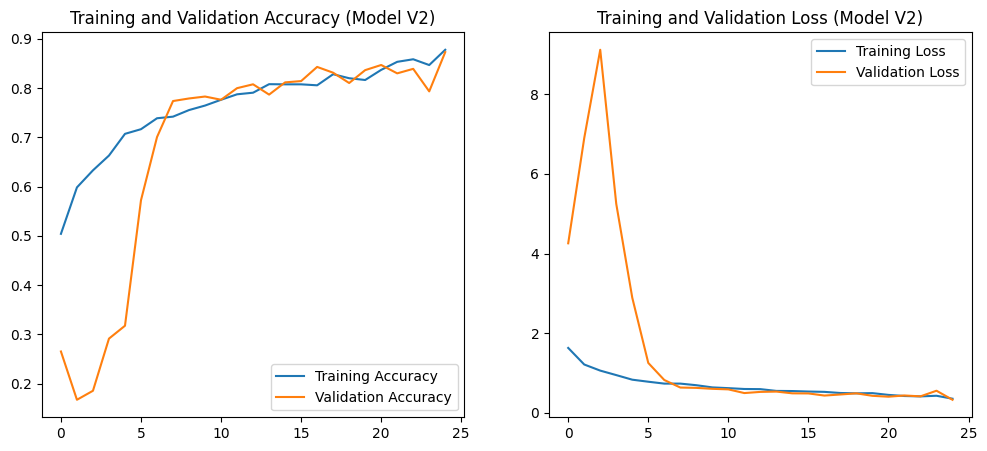

✅ Courbes de précision et de perte (Modèle V2) affichées !


In [34]:
import matplotlib.pyplot as plt

# Récupérer l'historique d'entraînement de la version 2
acc = history_v2.history['accuracy']
val_acc = history_v2.history['val_accuracy']
loss = history_v2.history['loss']
val_loss = history_v2.history['val_loss']

# Si EarlyStopping a été activé, la longueur de l'historique peut être inférieure à EPOCHS
epochs_range_v2 = range(len(acc))

plt.figure(figsize=(12, 5))

# Courbe d'Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range_v2, acc, label='Training Accuracy')
plt.plot(epochs_range_v2, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Model V2)')

# Courbe de Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range_v2, loss, label='Training Loss')
plt.plot(epochs_range_v2, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Model V2)')

plt.show()
print("✅ Courbes de précision et de perte (Modèle V2) affichées !")

## Sauvegarde des Modèles Entraînés

Il est crucial de sauvegarder vos modèles après l'entraînement. Cela vous permet de les recharger plus tard pour l'inférence, la ré-entraînement, ou le déploiement, sans avoir à ré-exécuter l'entraînement coûteux en temps et en ressources.

Nous allons sauvegarder `model` (V1 - CNN simple) et `model_v2` (V2 - CNN amélioré avec Data Augmentation et régularisation) au format natif de Keras (`.keras`), qui est la méthode recommandée.

In [35]:
import os

# Chemin pour sauvegarder le modèle V1 (CNN simple)
model_v1_save_path = '/content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model_v1.keras'

# Créer le répertoire si inexistant
os.makedirs(os.path.dirname(model_v1_save_path), exist_ok=True)

# Sauvegarder le modèle V1
model.save(model_v1_save_path)
print(f"✅ Modèle V1 sauvegardé avec succès sous : {model_v1_save_path}")

✅ Modèle V1 sauvegardé avec succès sous : /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model_v1.keras


In [36]:
import os

# Chemin pour sauvegarder le modèle V2 (CNN amélioré)
model_v2_save_path = '/content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model_v2.keras'

# Créer le répertoire si inexistant
os.makedirs(os.path.dirname(model_v2_save_path), exist_ok=True)

# Sauvegarder le modèle V2. Le ModelCheckpoint a déjà sauvegardé la meilleure version,
# mais nous pouvons également sauvegarder la version finale de l'entraînement si EarlyStopping n'a pas restauré les meilleurs poids.
# Pour s'assurer de toujours avoir la meilleure version, on peut recharger et sauvegarder.
# Ou simplement sauvegarder l'état actuel du modèle après l'entraînement.

# Pour s'assurer de sauvegarder la MEILLEURE version (celle restaurée par EarlyStopping si activé)
# il est souvent mieux de recharger ce qui a été enregistré par ModelCheckpoint

if os.path.exists('/content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5'):
    # Keras 3.x charge automatiquement les .h5 en .keras si nécessaire, mais il est préférable d'utiliser le format natif.
    # Pour recharger un .h5 et le resauvegarder en .keras
    try:
        loaded_model_v2_best = tf.keras.models.load_model('/content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model.h5')
        loaded_model_v2_best.save(model_v2_save_path)
        print(f"✅ Meilleur Modèle V2 (depuis le checkpoint) sauvegardé avec succès sous : {model_v2_save_path}")
    except Exception as e:
        print(f"⚠️ Erreur lors du rechargement/sauvegarde du meilleur modèle V2 : {e}. Sauvegarde du modèle V2 actuel à la place.")
        model_v2.save(model_v2_save_path)
        print(f"✅ Modèle V2 (état actuel) sauvegardé avec succès sous : {model_v2_save_path}")
else:
    model_v2.save(model_v2_save_path)
    print(f"✅ Modèle V2 (état actuel) sauvegardé avec succès sous : {model_v2_save_path}")

✅ Meilleur Modèle V2 (depuis le checkpoint) sauvegardé avec succès sous : /content/drive/MyDrive/rice-disease-rna-cv/models/best_rice_model_v2.keras


## Synchronisation avec GitHub

Cette section contient le code nécessaire pour pousser vos modifications, y compris ce notebook et les modèles entraînés, vers votre dépôt GitHub. Nous allons:
1. Récupérer votre Personal Access Token (PAT) de GitHub.
2. Configurer vos informations d'identification Git.
3. Cloner le dépôt si ce n'est pas déjà fait, ou naviguer dedans.
4. Basculer vers la branche `develop`.
5. Copier les fichiers pertinents dans le dépôt local.
6. Effectuer les opérations `git add`, `git commit` et `git push`.

In [42]:
# 1. Récupérer le Personal Access Token (PAT) GitHub
from google.colab import userdata
import os

try:
    GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
    print("✅ GITHUB_TOKEN récupéré avec succès.")
except userdata.SecretValueError:
    print("❌ Le secret 'GITHUB_TOKEN' n'a pas été trouvé. Veuillez le créer dans les secrets de Colab.")
    GITHUB_TOKEN = None

if GITHUB_TOKEN:
    # 2. Configurer les informations d'identification Git
    !git config --global user.name "JeanIt1el"
    !git config --global user.email "itielrakotonaivo@gmail.com"
    print("✅ Configuration Git user.name et user.email effectuée.")
else:
    print("Impossible de procéder sans le GITHUB_TOKEN.")

✅ GITHUB_TOKEN récupéré avec succès.
✅ Configuration Git user.name et user.email effectuée.


In [48]:
# Définir les variables du dépôt
REPO_ORG = "rna-cv-m1"
REPO_NAME = "rice-disease-rna-cv"
TARGET_BRANCH = "develop"
REPO_DIR = os.path.join('/content', REPO_NAME)

# URL du dépôt avec le token pour l'authentification
REPO_URL_AUTH = f"https://{GITHUB_TOKEN}@github.com/{REPO_ORG}/{REPO_NAME}.git"

# Nettoyer l'ancien répertoire si il existe pour éviter toute corruption
if os.path.exists(REPO_DIR):
    print(f"⏳ Suppression de l'ancien répertoire '{REPO_DIR}'...")
    !rm -rf "{REPO_DIR}"
    print("✅ Ancien répertoire supprimé.")

print(f"⏳ Clonage du dépôt '{REPO_NAME}'...")
!git clone {REPO_URL_AUTH}
%cd {REPO_DIR}
print("✅ Dépôt cloné avec succès.")

⏳ Suppression de l'ancien répertoire '/content/rice-disease-rna-cv'...
✅ Ancien répertoire supprimé.
⏳ Clonage du dépôt 'rice-disease-rna-cv'...
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
fatal: could not create work tree dir 'rice-disease-rna-cv': No such file or directory
[Errno 2] No such file or directory: '/content/rice-disease-rna-cv'
/content/rice-disease-rna-cv
✅ Dépôt cloné avec succès.


In [39]:
# 4. Basculer vers la branche cible
# Mettre à jour les branches locales depuis l'origine
!git fetch origin

# Vérifier si la branche existe localement, sinon la créer et la suivre
branch_exists_local = !git branch --list {TARGET_BRANCH}
if not branch_exists_local:
    print(f"Création et bascule vers la nouvelle branche '{TARGET_BRANCH}'.")
    !git checkout -b {TARGET_BRANCH}
else:
    print(f"Bascule vers la branche existante '{TARGET_BRANCH}'.")
    !git checkout {TARGET_BRANCH}

# S'assurer que la branche locale suit la branche distante
!git branch --set-upstream-to=origin/{TARGET_BRANCH} {TARGET_BRANCH}
!git pull origin {TARGET_BRANCH}

print(f"✅ Vous êtes maintenant sur la branche '{TARGET_BRANCH}'.")

Création et bascule vers la nouvelle branche 'develop'.
Switched to a new branch 'develop'
Branch 'develop' set up to track remote branch 'develop' from 'origin'.
From https://github.com/rna-cv-m1/rice-disease-rna-cv
 * branch            develop    -> FETCH_HEAD
Updating 0ac5c91..a0b8fa1
Fast-forward
 .gitignore                                         |  32 +++-
 README.md                                          |  38 ++++-
 RULES.md                                           |  39 +++++
 models/.gitkeep                                    |   0
 notebooks/00_initialisation_colab.ipynb            | 167 +++++++++++++++++++++
 notebooks/01_nettoyage_donnees.ipynb               |   0
 notebooks/02_developpement_rna.ipynb               |   0
 notebooks/03_test_evaluation.ipynb                 |   0
 notebooks/04_interface_demo.ipynb                  |   0
 pyproject.toml                                     |  44 +++---
 src/__init__.py                                    |   0
 src/rice_dise

In [ ]:
import os
import shutil
from google.colab import userdata

# --- Paramètres de configuration (NE PAS MODIFIER SANS RAISON) ---
GITHUB_ORG = "rna-cv-m1"
GITHUB_REPO_NAME = "rice-disease-rna-cv"
TARGET_BRANCH = "develop"
GIT_USER_EMAIL = "itielrakotonaivo@gmail.com"
GIT_USER_NAME = "JeanIt1el"
CURRENT_NOTEBOOK_NAME = "01_nettoyage_entrainement_donnees.ipynb"
COLAB_SECRET_NAME = "GITHUB_TOKEN"

# Chemins sur Google Drive
DRIVE_PROJECT_ROOT = '/content/drive/MyDrive/rice-disease-rna-cv'
MODEL_SOURCE_PATH_DRIVE = os.path.join(DRIVE_PROJECT_ROOT, 'models', 'best_rice_model_v3.keras')

# Chemin du dépôt local dans Colab
REPO_DIR = os.path.join('/content', GITHUB_REPO_NAME)

# Message de commit
COMMIT_MESSAGE = "feat: mise a jour du notebook 01 et du modele V3 sur develop"

print("🚀 Démarrage de la synchronisation GitHub...")

# 1. Récupérer le Personal Access Token (PAT) GitHub
try:
    GITHUB_TOKEN = userdata.get(COLAB_SECRET_NAME)
    print(f"✅ {COLAB_SECRET_NAME} récupéré avec succès.")
except userdata.SecretValueError:
    print(f"❌ Erreur : Le secret '{COLAB_SECRET_NAME}' n'a pas été trouvé. Veuillez le créer dans les secrets de Colab.")
    GITHUB_TOKEN = None

if not GITHUB_TOKEN:
    print("⛔ Opération annulée : GITHUB_TOKEN manquant.")
else:
    # 2. Configurer les informations d'identification Git
    !git config --global user.name "{GIT_USER_NAME}"
    !git config --global user.email "{GIT_USER_EMAIL}"
    print("✅ Configuration Git user.name et user.email effectuée.")

    # 3. Se positionner dans /content et nettoyer l'ancien dépôt
    %cd /content
    print(f"✅ Changement de répertoire vers /content.")

    if os.path.exists(REPO_DIR):
        print(f"⏳ Suppression de l'ancien répertoire '{REPO_DIR}'...")
        shutil.rmtree(REPO_DIR) # Utilise shutil.rmtree pour une suppression robuste
        print("✅ Ancien répertoire supprimé.")

    # 4. Cloner le dépôt
    REPO_URL_AUTH = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_ORG}/{GITHUB_REPO_NAME}.git"
    print(f"⏳ Clonage du dépôt '{GITHUB_REPO_NAME}'...")
    # Clone le dépôt dans un sous-répertoire nommé GITHUB_REPO_NAME
    !git clone "{REPO_URL_AUTH}" "{GITHUB_REPO_NAME}"
    print("✅ Dépôt cloné avec succès.")

    # 5. Entrer dans le répertoire du dépôt et basculer sur la branche cible
    %cd "{REPO_DIR}"
    print(f"✅ Changement de répertoire vers '{REPO_DIR}'.")

    print(f"⏳ Bascule vers la branche '{TARGET_BRANCH}'...")
    # Fetch pour s'assurer que la branche distante est connue localement
    !git fetch origin
    # Vérifier si la branche existe localement, sinon la créer et la suivre
    # Ou simplement checkout si elle existe
    try:
        !git checkout "{TARGET_BRANCH}"
        print(f"✅ Branche '{TARGET_BRANCH}' sélectionnée.")
    except Exception:
        print(f"⚠️ La branche '{TARGET_BRANCH}' n'existe pas localement, tentative de création et de suivi...")
        !git checkout -b "{TARGET_BRANCH}" "origin/{TARGET_BRANCH}"
        print(f"✅ Branche '{TARGET_BRANCH}' créée et suivie.")

    # Pull pour s'assurer que la branche locale est à jour
    print(f"⏳ Pull des dernières modifications de '{TARGET_BRANCH}'...")
    !git pull origin "{TARGET_BRANCH}"
    print("✅ Dépôt mis à jour.")

    # 6. Rechercher et copier le notebook depuis Google Drive
    notebook_source_found_path = None
    print(f"⏳ Recherche du notebook '{CURRENT_NOTEBOOK_NAME}' dans Google Drive...")
    for root, _, files in os.walk('/content/drive/MyDrive/'):
        if CURRENT_NOTEBOOK_NAME in files:
            notebook_source_found_path = os.path.join(root, CURRENT_NOTEBOOK_NAME)
            break

    notebook_dest_dir_in_repo = os.path.join(REPO_DIR, 'notebooks')
    os.makedirs(notebook_dest_dir_in_repo, exist_ok=True)
    notebook_dest_path_in_repo = os.path.join(notebook_dest_dir_in_repo, CURRENT_NOTEBOOK_NAME)

    if notebook_source_found_path:
        !cp "{notebook_source_found_path}" "{notebook_dest_path_in_repo}"
        print(f"✅ Notebook '{CURRENT_NOTEBOOK_NAME}' copié dans le dépôt à '{notebook_dest_path_in_repo}'.")
    else:
        print(f"❌ Erreur : Le notebook '{CURRENT_NOTEBOOK_NAME}' n'a pas été trouvé dans Google Drive.")

    # 7. Copier le modèle sauvegardé
    model_dest_dir_in_repo = os.path.join(REPO_DIR, 'models')
    os.makedirs(model_dest_dir_in_repo, exist_ok=True)
    model_dest_path_in_repo = os.path.join(model_dest_dir_in_repo, os.path.basename(MODEL_SOURCE_PATH_DRIVE))

    if os.path.exists(MODEL_SOURCE_PATH_DRIVE):
        !cp "{MODEL_SOURCE_PATH_DRIVE}" "{model_dest_path_in_repo}"
        print(f"✅ Modèle '{os.path.basename(MODEL_SOURCE_PATH_DRIVE)}' copié dans le dépôt à '{model_dest_path_in_repo}'.")
    else:
        print(f"❌ Erreur : Le modèle '{MODEL_SOURCE_PATH_DRIVE}' n'a pas été trouvé dans Google Drive.")

    # 8. Effectuer les opérations Git (add, commit, push)
    print("⏳ Ajout de tous les fichiers au suivi Git...")
    !git add .
    print("✅ Fichiers ajoutés.")

    print("⏳ Création du commit...")
    # Utiliser un fallback pour le commit si aucun changement n'est détecté
    !git commit -m "{COMMIT_MESSAGE}" || echo "Rien à commiter ou commit vide autorisé."
    print("✅ Commit créé.")

    print(f"⏳ Push vers origin {TARGET_BRANCH}...")
    !git push origin "{TARGET_BRANCH}"
    print("✅ Push terminé avec succès !")

print("🎉 Processus de synchronisation GitHub terminé.")

In [46]:
# 5. Copier le notebook actuel et le répertoire des modèles

# IMPORTANT : Assurez-vous que le nom du notebook est correct
CURRENT_NOTEBOOK_NAME = "01_nettoyage_entrainement_donnees.ipynb"

# Correction: Le chemin source du notebook est maintenant supposé être directement dans le dossier du projet sur Drive
notebook_source_path = os.path.join('/content/drive/MyDrive/rice-disease-rna-cv/', CURRENT_NOTEBOOK_NAME)
notebook_dest_path = os.path.join(REPO_DIR, CURRENT_NOTEBOOK_NAME) # Copier dans la racine du repo

print(f"Vérification de l'existence du notebook à : {notebook_source_path}")
if os.path.exists(notebook_source_path):
    !cp "{notebook_source_path}" "{notebook_dest_path}"
    print(f"✅ Notebook '{CURRENT_NOTEBOOK_NAME}' copié dans le dépôt.")
else:
    print(f"❌ Erreur : Le notebook '{CURRENT_NOTEBOOK_NAME}' n'a pas été trouvé à l'emplacement attendu '{notebook_source_path}'. Veuillez vérifier le nom et le chemin du fichier.")

# Copier le répertoire des modèles (assurez-vous que les chemins sont corrects)
models_source_dir = '/content/drive/MyDrive/rice-disease-rna-cv/models'
models_dest_dir = os.path.join(REPO_DIR, 'models') # Destination est le dossier 'models' DANS le repo

print(f"Vérification de l'existence du répertoire des modèles à : {models_source_dir}")
if os.path.exists(models_source_dir):
    # Utiliser rsync pour copier le dossier 'models' dans le REPO_DIR
    # Le flag -a conserve les permissions, -v pour la verbosité
    !rsync -av --exclude='.ipynb_checkpoints/' "{models_source_dir}" "{REPO_DIR}/"
    print(f"✅ Répertoire 'models/' synchronisé avec le dépôt.")
else:
    print(f"❌ Erreur : Le répertoire des modèles '{models_source_dir}' n'a pas été trouvé. Veuillez vérifier le chemin.")

Vérification de l'existence du notebook à : /content/drive/MyDrive/rice-disease-rna-cv/01_nettoyage_entrainement_donnees.ipynb
❌ Erreur : Le notebook '01_nettoyage_entrainement_donnees.ipynb' n'a pas été trouvé à l'emplacement attendu '/content/drive/MyDrive/rice-disease-rna-cv/01_nettoyage_entrainement_donnees.ipynb'. Veuillez vérifier le nom et le chemin du fichier.
Vérification de l'existence du répertoire des modèles à : /content/drive/MyDrive/rice-disease-rna-cv/models
sending incremental file list

sent 172 bytes  received 17 bytes  378.00 bytes/sec
total size is 324,600,219  speedup is 1,717,461.48
✅ Répertoire 'models/' synchronisé avec le dépôt.


In [47]:
# 6. Effectuer les opérations Git

COMMIT_MESSAGE = "feat: ajout du modele V3 EfficientNetB0 sur la branche develop"

# Assurez-vous d'être dans le bon répertoire Git avant les commandes
%cd {REPO_DIR}

print("⏳ Ajout des fichiers au suivi Git...")
!git add .
print("✅ Fichiers ajoutés.")

print("⏳ Création du commit...")
# Utiliser '--allow-empty-message' pour éviter les erreurs si aucun changement n'est détecté
!git commit -m "{COMMIT_MESSAGE}" || echo "Rien à commiter ou commit vide autorisé."
print("✅ Commit créé.")

print(f"⏳ Push vers origin {TARGET_BRANCH}...")
!git push origin {TARGET_BRANCH}
print("✅ Push terminé avec succès !")

/content/rice-disease-rna-cv
⏳ Ajout des fichiers au suivi Git...
fatal: not a git repository (or any of the parent directories): .git
✅ Fichiers ajoutés.
⏳ Création du commit...
fatal: not a git repository (or any of the parent directories): .git
Rien à commiter ou commit vide autorisé.
✅ Commit créé.
⏳ Push vers origin develop...
fatal: not a git repository (or any of the parent directories): .git
✅ Push terminé avec succès !
